# Benchmarking V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [74]:
import multiprocessing
import warnings

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from typing import Callable, Dict, List, Literal, NamedTuple, Tuple, Type

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.utils import check_random_state

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [69]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'api', 'config', 'grids']
Classes: ['CARVE']
Functions: []


In [70]:
from carve import CARVE
from carve.config import ValidatorConfig

---

## 1. Data Simulation:

In [ ]:
def _validate_center_box(center_box: float) -> float:
    if center_box < 0:
        warnings.warn('`center_box` should be positive; using abs(center_box).')
        center_box = -center_box
    if center_box == 0.0:
        warnings.warn('`center_box` was 0; defaulting to 10.0.')
        center_box = 10.0
    return center_box

def _lhs_centers(k: int, p: int, center_box: float, rng: np.random.Generator) -> np.ndarray:
    # latin hypercube: each dim gets a random permutation of k bins, with jitter inside each bin
    X = np.empty((k, p), dtype=float)
    
    for j in range(p):
        perm = rng.permutation(k)
        u = (perm + rng.random(k)) / k  # jitter inside each bin -> U(0,1)
        X[:, j] = -center_box + (2 * center_box) * u
        
    return X

def _best_candidate_centers(k: int, p: int, center_box: float, rng: np.random.Generator, n_candidates: int = 64) -> np.ndarray:
    centers = np.empty((k, p), dtype=float)
    centers[0] = rng.uniform(-center_box, center_box, size=p)
    
    for i in range(1, k):
        cands = rng.uniform(-center_box, center_box, size=(n_candidates, p))
        
        # compute squared distances to existing centers
        diffs = cands[:, None, :] - centers[None, :i, :]
        d2 = np.sum(diffs**2, axis=2)
        min_d2 = d2.min(axis=1)
        centers[i] = cands[np.argmax(min_d2)]
        
    return centers

def _min_dist_centers(k: int, p: int, center_box: float, rng: np.random.Generator, min_center_dist: float, max_tries: int = 200000) -> np.ndarray:
    centers = []
    tries = 0
    min2 = min_center_dist ** 2
    
    while len(centers) < k and tries < max_tries:
        c = rng.uniform(-center_box, center_box, size=p)
        if not centers:
            centers.append(c)
        else:
            cc = np.vstack(centers)
            if np.all(np.sum((cc - c) ** 2, axis=1) >= min2):
                centers.append(c)
        tries += 1
        
    if len(centers) < k:
        raise ValueError(f"could not place {k} centers with min_center_dist={min_center_dist}. try reducing it or enlarging center_box.")
    
    return np.vstack(centers)

def _sample_cluster_sizes(
    n_total: int,
    k: int,
    rng: np.random.Generator,
    min_abs: int = 5,
    min_frac: float = 0.1,
    alpha: float | np.ndarray = 0.3,
    ensure_nonempty: bool = True
) -> np.ndarray:
    """
    Returns integer sizes summing to n_total with floors enforced.
    Strategy: allocate the guaranteed minimum first, then distribute the remainder
    via Multinomial with probabilities from a Dirichlet(alpha).
    """
    if n_total <= 0 or k <= 0:
        raise ValueError("n_total and k must be positive.")
    if min_abs < 0 or min_frac < 0:
        raise ValueError("min_abs and min_frac must be nonnegative.")
    if isinstance(alpha, np.ndarray) and alpha.shape != (k,):
        raise ValueError("alpha must be scalar or shape (k,).")

    # per-cluster floor
    floor_each = max(min_abs, int(np.ceil(min_frac * n_total)))
    if ensure_nonempty:
        floor_each = max(floor_each, 1)

    total_floor = floor_each * k
    if total_floor > n_total:
        raise ValueError(
            f"Infeasible: k * floor_each = {k} * {floor_each} = {total_floor} > n_total = {n_total}. "
            "Reduce k / floors or increase n_total."
        )

    # assign floors, then distribute the remainder
    sizes = np.full(k, floor_each, dtype=int)
    remaining = n_total - total_floor
    if remaining == 0:
        return sizes

    # Dirichlet probs -> Multinomial integer split
    a = np.full(k, alpha, dtype=float) if np.isscalar(alpha) else alpha.astype(float)
    probs = rng.dirichlet(a)
    sizes += rng.multinomial(remaining, probs)
    return sizes

def _parse_outliers(outliers: int | float, n_total: int) -> int:
    if isinstance(outliers, float) and 0 < outliers < 1:
        return int(np.floor(n_total * outliers))
    elif isinstance(outliers, int) and outliers >= 0:
        return outliers
    else:
        warnings.warn("`outliers` must be a non-negative int or a float in (0, 1). Defaulting to 0.")
        return 0

def _compute_cluster_sizes(
    *, n_total_clusters: int, k: int, balanced: bool,
    cluster_sizes_frac: list[float] | None,
    rng: np.random.Generator,
    min_abs: int, min_frac: float, alpha: float | np.ndarray
) -> np.ndarray:
    if cluster_sizes_frac is not None:
        if len(cluster_sizes_frac) != k:
            raise ValueError(f"cluster_sizes_frac must have length k={k}.")
        
        total = float(np.sum(cluster_sizes_frac))
        if abs(total - 1.0) > 1e-8:
            warnings.warn("`cluster_sizes_frac` does not add up to 1. Rescaling cluster_sizes_frac.")
            cluster_sizes_frac = [frac / total for frac in cluster_sizes_frac]
        sizes = [int(np.floor(n_total_clusters * frac)) for frac in cluster_sizes_frac]
        
        # distribute remainder
        for i in range(n_total_clusters - int(np.sum(sizes))):
            sizes[i % k] += 1
        
        return np.asarray(sizes, dtype=int)

    elif balanced:
        base = n_total_clusters // k
        sizes = [base] * k
        for i in range(n_total_clusters - base * k):
            sizes[i] += 1
        return np.asarray(sizes, dtype=int)

    else:  # unbalanced with constraints
        return _sample_cluster_sizes(
            n_total=n_total_clusters,
            k=k,
            rng=rng,
            min_abs=min_abs,
            min_frac=min_frac,
            alpha=alpha
        )

def _get_cluster_scales(cluster_scale, k: int) -> list[float]:
    if callable(cluster_scale):
        return [float(cluster_scale()) for _ in range(k)]
    
    elif isinstance(cluster_scale, list):
        if len(cluster_scale) != k:
            raise ValueError("Passed `cluster_scale` parameter must be of size k.")
        return [float(x) for x in cluster_scale]
    
    else:
        return [float(cluster_scale)] * k

def _sample_centers(
    *, k: int, p: int, center_box: float, rng: np.random.Generator,
    method: Literal["none", "lhs", "best_candidate", "min_dist"],
    n_candidates: int, min_center_dist: float | None
) -> np.ndarray:
    center_box = _validate_center_box(center_box)
    if method == "none":
        return rng.uniform(-center_box, center_box, size=(k, p))
    
    elif method == "lhs":
        return _lhs_centers(k, p, center_box, rng)
    
    elif method == "best_candidate":
        return _best_candidate_centers(k, p, center_box, rng, n_candidates=n_candidates)
    
    elif method == "min_dist":
        if min_center_dist is None:
            diag = 2 * center_box * np.sqrt(p)
            min_center_dist = 0.05 * diag
        return _min_dist_centers(k, p, center_box, rng, min_center_dist=min_center_dist)
    
    else:
        raise ValueError(f"unknown centroid_method: {method}")

def _build_correlation_matrix(
    *, p: int, corr_type: Literal["none", "ar1", "block"], corr_strength: float, block_size: int | None
) -> np.ndarray:
    if corr_type == "none":
        return np.eye(p)
    
    elif corr_type == "ar1":
        idx = np.arange(p)
        return corr_strength ** np.abs(idx[:, None] - idx[None, :])
    
    elif corr_type == "block":
        if block_size is None:
            raise ValueError("`block_size` must be provided when corr_type='block'")
        
        R = np.zeros((p, p))
        for start in range(0, p, block_size):
            end = min(start + block_size, p)
            R[start:end, start:end] = corr_strength
        np.fill_diagonal(R, 1.0)
        
        return R
    
    else:
        raise ValueError(f"Unknown corr_type `{corr_type}`")

def _cluster_covariances(scales: list[float], R: np.ndarray) -> list[np.ndarray]:
    return [s * R for s in scales]

def _sample_cluster_points(
    *, rng: np.random.Generator, size: int, mean: np.ndarray, cov: np.ndarray,
    distribution: Literal["gaussian", "t", "uniform_ball"], t_df: int
) -> np.ndarray:
    p = mean.shape[0]
    if size == 0:
        return np.empty((0, p), dtype=float)

    if distribution == "gaussian":
        return rng.multivariate_normal(mean=mean, cov=cov, size=size)
    
    elif distribution == "t":
        # X = μ + L z * sqrt(df / v), z~N(0,I), v~χ²(df)
        L = np.linalg.cholesky(cov)
        z = rng.standard_normal((size, p))
        v = rng.chisquare(t_df, size=(size, 1))
        return mean + (z @ L.T) * np.sqrt(t_df / v)
    
    elif distribution == "uniform_ball":
        # uniform in p-ball, radius tied to covariance scale
        r_max = np.sqrt(np.trace(cov) / p)
        U = rng.standard_normal((size, p))
        U /= np.linalg.norm(U, axis=1, keepdims=True)
        radii = rng.random(size) ** (1.0 / p) * r_max
        return mean + U * radii.reshape(-1, 1)

    else:
        raise ValueError("`distribution` must be one of: {'gaussian', 't', 'uniform_ball'}.")

def _sample_outliers(
    *, rng: np.random.Generator, n_outliers: int, p: int,
    centers: np.ndarray, cluster_sizes: np.ndarray, covs: list[np.ndarray],
    center_box: float, outlier_mode: Literal["far_gaussian", "uniform_box"], outlier_scale: float
) -> np.ndarray:
    if n_outliers <= 0:
        return np.empty((0, p), dtype=float)

    # weighted centroid + avg covariance
    weights = cluster_sizes.astype(float)
    global_centroid = np.average(centers, axis=0, weights=weights)
    avg_cov = sum(w * C for w, C in zip(weights, covs)) / weights.sum()
    global_sigma = float(np.sqrt(np.mean(np.diag(avg_cov))))

    if outlier_mode == "far_gaussian":
        U = rng.standard_normal(size=(n_outliers, p))
        U /= np.linalg.norm(U, axis=1, keepdims=True)
        return global_centroid + outlier_scale * global_sigma * U

    elif outlier_mode == "uniform_box":
        box = _validate_center_box(center_box) * outlier_scale
        return rng.uniform(-box, +box, size=(n_outliers, p))

    else:
        raise ValueError(f"unknown outlier_mode `{outlier_mode}`")

def _apply_embedding(
    X: np.ndarray, *, nonlinear: bool, method: Literal["random_fourier", "poly", "rbf"],
    embed_dim: int | None, embed_param: float, rng: np.random.Generator
) -> np.ndarray:
    if not nonlinear:
        return X

    if method == "random_fourier":
        if embed_dim is None:
            raise ValueError("embed_dim must be provided for random_fourier")
        freq_scale = 0.1
        W = rng.normal(scale=freq_scale, size=(X.shape[1], embed_dim))
        b = rng.uniform(0, 2 * np.pi, size=(embed_dim,))
        return np.sin(X @ W + b)

    elif method == "poly":
        d = embed_param
        # simple example: original + power + pairwise product of first two dims (if present)
        cols = [X, X**d]
        if X.shape[1] >= 2:
            cols.append((X[:, [0]] * X[:, [1]]))
        return np.hstack(cols)

    elif method == "rbf":
        sigma_rbf = embed_param
        m = min(50, len(X))
        prototypes = X[rng.choice(len(X), size=m, replace=False)]
        gamma = 1.0 / (2.0 * sigma_rbf**2)
        return np.exp(-gamma * ((X[:, None, :] - prototypes[None, :, :]) ** 2).sum(-1))

    else:
        raise ValueError(f"Unknown embed_method `{method}`")

def _plot_simulation(X: np.ndarray, y: np.ndarray, *, random_state: int | None):
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', edgecolors='k', alpha=0.8)
    plt.title("PCA projection of simulated clusters")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.legend(*scatter.legend_elements(), title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout(); plt.show()

class SimulationMeta(NamedTuple):
    centers: np.ndarray
    cluster_sizes: np.ndarray
    cluster_scales: list[float]
    correlation: np.ndarray
    covariances: list[np.ndarray]
    outliers: int

In [75]:
def simulate_clusters(
    n_total: int,
    p: int,
    k: int,
    cluster_scale: float | list[float] | Callable[[], float] = 1.0,
    balanced: bool = True,
    cluster_sizes_frac: list[float] | None = None,
    min_cluster_size_abs: int = 5,
    min_cluster_size_frac: float = 0.1,
    cluster_size_dirichlet_alpha: float | np.ndarray = 0.3,
    corr_type: Literal["none", "ar1", "block"] = "none",
    corr_strength: float = 1.0,
    block_size: int | None = None,
    outliers: int | float = 0,
    outlier_scale: float = 5.0,
    outlier_mode: Literal["far_gaussian", "uniform_box"] = "far_gaussian",
    distribution: Literal["gaussian", "t", "uniform_ball"] = "gaussian",
    t_df: int = 3,
    nonlinear: bool = False,
    embed_dim: int | None = None,
    embed_method: Literal["random_fourier", "poly", "rbf"] = "random_fourier",
    embed_param: float = 2.0,
    center_box: float = 10.0,
    centroid_method: Literal["none", "lhs", "best_candidate", "min_dist"] = "best_candidate",
    n_candidates: int = 64,
    min_center_dist: float | None = None,
    plotting: bool = True,
    random_state: int | None = None
) -> Tuple[np.ndarray, np.ndarray, SimulationMeta]:
    """
    Generate synthetic clustered data with optional correlation, outliers, and embedding.

    Returns: (X, y, meta)
      - X: (n_total, p) array
      - y: (n_total,) labels, 0..k-1 for clusters, -1 for outliers
      - meta: SimulationMeta with centers, sizes, scales, correlation, covariances, outliers
    """
    rng = np.random.default_rng(seed=random_state)

    # Outliers
    n_outliers = _parse_outliers(outliers, n_total)
    n_total_clusters = n_total - n_outliers
    if n_total_clusters < 1:
        raise ValueError("`outliers` too large, no points left for clusters.")

    # Sizes
    cluster_sizes = _compute_cluster_sizes(
        n_total_clusters=n_total_clusters,
        k=k,
        balanced=balanced,
        cluster_sizes_frac=cluster_sizes_frac,
        rng=rng,
        min_abs=min_cluster_size_abs,
        min_frac=min_cluster_size_frac,
        alpha=cluster_size_dirichlet_alpha
    )
    assert int(cluster_sizes.sum()) == n_total_clusters

    # Centers and covariances
    centers = _sample_centers(
        k=k, p=p, center_box=center_box, rng=rng,
        method=centroid_method, n_candidates=n_candidates, min_center_dist=min_center_dist
    )
    scales = _get_cluster_scales(cluster_scale, k)
    R = _build_correlation_matrix(p=p, corr_type=corr_type, corr_strength=corr_strength, block_size=block_size)
    covs = _cluster_covariances(scales, R)

    # Sample clusters
    X_parts: list[np.ndarray] = []
    y_parts: list[np.ndarray] = []
    for c in range(k):
        size = int(cluster_sizes[c])
        mean = centers[c]
        cov = covs[c]
        X_c = _sample_cluster_points(
            rng=rng, size=size, mean=mean, cov=cov,
            distribution=distribution, t_df=t_df
        )
        X_parts.append(X_c)
        y_parts.append(np.full(size, c, dtype=int))

    # Outliers
    if n_outliers > 0:
        X_out = _sample_outliers(
            rng=rng, n_outliers=int(n_outliers), p=p,
            centers=centers, cluster_sizes=cluster_sizes, covs=covs,
            center_box=center_box, outlier_mode=outlier_mode, outlier_scale=outlier_scale
        )
        X_parts.append(X_out)
        y_parts.append(np.full(int(n_outliers), -1, dtype=int))

    # Concatenate and shuffle
    X = np.vstack(X_parts) if X_parts else np.empty((0, p), dtype=float)
    y = np.concatenate(y_parts) if y_parts else np.empty((0,), dtype=int)

    perm = rng.permutation(len(y))
    X = X[perm]
    y = y[perm]

    # Optional embedding
    X = _apply_embedding(
        X, nonlinear=nonlinear, method=embed_method, embed_dim=embed_dim,
        embed_param=embed_param, rng=rng
    )

    # Optional plotting
    if plotting:
        _plot_simulation(X, y, random_state=random_state)

    meta = SimulationMeta(
        centers=centers, cluster_sizes=cluster_sizes, cluster_scales=scales,
        correlation=R, covariances=covs, outliers=int(n_outliers)
    )
    return X, y, meta

---

## 2. Benchmarking

In [82]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


Gap-Statistics:

In [83]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Compute within-cluster dispersion W_k.

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']

    :return: within-cluster dispersion W_k
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, _: int, random_state: int) -> np.ndarray:
    """
    Generate a single null-distribution dataset.

    :param X: reference dataset
    :param _: dummy index for Parallel
    :param random_state: random state for the random number generator
    
    :return: null-distribution dataset of same shape as X
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the gap statistic for a given clustering assignment, as introduced by Tibshirani et al. (2001).

    :param X: data matrix on which clusters were computed
    :param labels: cluster labels for X
    :param metric: the distance metric to be used when calculating pairwise distances. Valid values are: 
        From scikit-learn: ['cityblock', 'cosine', 'euclidean', 'l1', 'l2', 'manhattan', 'nan_euclidean']
        From scipy.spatial.distance: ['braycurtis', 'canberra', 'chebyshev', 'correlation', 'dice', 'hamming', 'jaccard', 'kulsinski', 
            'mahalanobis', 'minkowski', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath', 'sqeuclidean', 'yule']
    :param n_refs: number of reference datasets to generate under the null hypothesis (no clustering structure)
    :param algorithm: sklearn clustering algorithm to cluster the null-distribution dataset
    :param random_state: a random state

    :return: The gap statistic; difference between the expected log within-cluster dispersion 
        under the null model and the observed log dispersion from the provided clustering
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, i, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k, n_init='auto', random_state=rng.randint(0,1e6))
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

Benchmarking code:

In [84]:
def calculate_metric(X: np.ndarray, labels: np.ndarray, metric: str) -> float:
    if metric == 'gap':
        return gap_statistic(X, labels)

    elif metric == 'silhouette':
        return silhouette_score(X, labels)
    
    else:
        raise ValueError(f"Unknown metric: {metric}")

In [96]:
def alpha_to_mult(alpha: float, mult_range: Tuple[float, float] = (0.2, 4.0), mode: str = "linear") -> float:
    a = float(np.clip(alpha, 0.0, 1.0))
    low, high = mult_range
    
    if mode == 'log':
        return low * (high / low) ** a
    
    return low + a * (high)

def sim_alpha(
    *,
    alpha: float,
    k: int,
    seed: int,
    n_total: int,
    p: int,
    settings_by_k: Dict[int, Dict[str, List[float]]],
    mult_range: Tuple[float, float] = (0.2, 4.0),
    mult_mode: str = "linear",
    plotting: bool = False,
    **extra_sim_kwargs,
) -> Tuple[np.ndarray, np.ndarray]:
    cfg = settings_by_k[k]
    base_scales = cfg['cluster_scales']
    sizes_frac = cfg['cluster_sizes']
    
    if len(base_scales) != k or len(sizes_frac) != k:
        raise ValueError(f"settings_by_k[{k}] must have {k} scales and {k} sizes")
    
    mult = alpha_to_mult(alpha, mult_range, mult_mode)
    scales = [s * mult for s in base_scales]
    
    X, y, _ = simulate_clusters(
        n_total=n_total,
        p=p,
        k=k,
        balanced=False,
        cluster_scale=scales,
        cluster_sizes_frac=sizes_frac,
        plotting=plotting,
        random_state=seed,
        **extra_sim_kwargs,
    )
    
    return X, y

In [97]:
def benchmark_cluster_metrics(
    settings_by_k, 
    alphas=np.logspace(np.log10(0.01), np.log10(1.0), 10),
    B=100,
    model_grids=None,
    true_ks=[3, 4, 5, 6],
    test_ks=range(2, 7+1),
    external_metrics=["silhouette", "gap"],
    random_state=42
):
    """
    Benchmark cluster validation metrics against datasets of varying difficulty.
    
    Parameters:
    -----------
    alphas : list of float
        Difficulty levels from 0 (easy) to 1 (hard)
    true_ks : list of int
        True number of clusters to generate
    test_ks : list of int
        K values to test for each metric
    metrics : list of str
        Metrics to evaluate
    n_datasets : int
        Number of datasets to generate per configuration
    
    Returns:
    --------
    pandas.DataFrame
        Results containing all evaluation data
    """
    results = []

    CARVE_AVAILABLE_METRICS = [
        'ari_stability', 'ari_generalizability', 
        'ari_stability_1se', 'ari_generalizability_1se', 
        'consensus_pac_stability'
    ]

    total_steps = len(alphas) * B * len(true_ks)
    pbar = tqdm(total=total_steps, desc="Benchmarking", leave=True)
    for alpha in alphas:
        for seed in range(B):
            for true_k in true_ks:
                # Generate dataset with difficulty alpha and true_k clusters
                X, y = sim_alpha(
                    alpha=alpha, k=true_k, seed=random_state+seed,
                    n_total=500, p=2,
                    settings_by_k=settings_by_k,
                    mult_range=(0.2, 4.0), mult_mode="linear",
                    plotting=False
                )
                
                # fit and evaluate CARVE
                if model_grids is None:
                    # D2 = pairwise_distances(X, metric='sqeuclidean')
                    # median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
                    # gamma0 = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0
                    
                    model_grids = [
                        (KMeans, {"n_clusters": test_ks}),
                        # (AgglomerativeClustering, {"n_clusters": test_ks, "linkage": ["ward"]}),
                        # (SpectralClustering, {"n_clusters": test_ks, "gamma": [gamma0]})
                    ]

                cfg = ValidatorConfig(
                    X=X,
                    ref_labels=y,
                    model_grids=model_grids
                )

                val = CARVE(cfg)
                val.validate(prog_bar=False, random_state=seed)
                
                for carve_metric in CARVE_AVAILABLE_METRICS:
                    rule = '1se' if carve_metric.endswith('_1se') else 'max'
                    
                    if carve_metric.endswith('_1se'):
                        measure = carve_metric[:-4]
                    else:
                        measure = carve_metric
                            
                    optimal_k = val.get_optimal_k(measure=measure, rule=rule)
                    
                    for k in test_ks:
                        value = val.model_df[measure].loc[val.model_df['n_clusters'] == k].values[0]
                        results.append({
                            'alpha': alpha,
                            'metric_name': carve_metric,
                            'true_k': true_k,
                            'k': k,
                            'metric_value': value,
                            'is_optimal': k == optimal_k,
                            'is_correct': k == true_k,
                            'dataset_id': seed
                        })
                
                # evaluate external metrics
                for metric in external_metrics:
                    metric_values = []
                    
                    # Calculate metric value for each test_k
                    for k in test_ks:
                        labels = val.get_optimal_labels(k=k)
                        value = calculate_metric(X, labels, metric)
                        metric_values.append((k, value))
                    
                    # Find the k where respective metric is maximized
                    optimal_k, _ = max(metric_values, key=lambda x: x[1])
                    
                    # Record all results
                    for k, value in metric_values:
                        results.append({
                            'alpha': alpha,
                            'metric_name': metric,
                            'true_k': true_k,
                            'k': k,
                            'metric_value': value,
                            'is_optimal': k == optimal_k,
                            'is_correct': k == true_k,
                            'dataset_id': seed
                        })

                pbar.update(1)
    
    pbar.close()
    return pd.DataFrame(results)

Output plotting:

In [98]:
def plot_accuracy_vs_alpha(results_df):
    # Group by alpha and metric, calculate accuracy
    accuracy_df = (results_df[results_df['is_optimal']]
                   .groupby(['alpha', 'metric_name', 'dataset_id'])
                   .agg({'is_correct': 'mean'})
                   .reset_index()
                   .groupby(['alpha', 'metric_name'])
                   .agg({'is_correct': ['mean', 'std']})
                   .reset_index())
    
    # Plot
    plt.figure(figsize=(12, 8))
    for metric in accuracy_df['metric_name'].unique():
        subset = accuracy_df[accuracy_df['metric_name'] == metric]
        plt.plot(subset['alpha'], subset[('is_correct', 'mean')], marker='o', label=metric)
        plt.fill_between(
            subset['alpha'],
            subset[('is_correct', 'mean')] - subset[('is_correct', 'std')],
            subset[('is_correct', 'mean')] + subset[('is_correct', 'std')],
            alpha=0.2
        )
    
    plt.xlabel('Difficulty (alpha)')
    plt.ylabel('Accuracy')
    plt.title('Metric Accuracy vs. Problem Difficulty')
    plt.legend()
    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()

In [99]:
def plot_metric_lineplots_grid(results_df, alphas, show_majority_votes=True, metrics_to_display=None, figsize=None):
    """
    Plot a grid of line plots showing metrics vs k with different alpha values.
    
    Parameters:
    -----------
    results_df : pandas DataFrame
        Results from benchmark_cluster_metrics
    alphas : list of float
        All alpha values tested
    metrics_to_display : list of str, optional
        Names of metrics to display. If None, all metrics are displayed.
    figsize : tuple, optional
        Figure size in inches (width, height). If None, auto-calculated.
    """
    EXCLUDE = {"ari_stability_1se", "ari_generalizability_1se"}
    
    # Select three anchor alpha values (first, middle, last)
    anchors = [alphas[0], alphas[len(alphas)//2], alphas[-1]]
    
    # Filter metrics if specified
    all_metrics = sorted(results_df['metric_name'].unique())
    if metrics_to_display is not None:
        metrics = [
            m for m in metrics_to_display
            if (m in all_metrics) and (m not in EXCLUDE)
        ]
        
        if not metrics:
            raise ValueError(f"None of the provided metrics {metrics_to_display} found in data")
    else:
        metrics = [m for m in all_metrics if m not in EXCLUDE]
    
    true_ks = sorted(results_df['true_k'].unique())
    
    # Calculate figure size if not provided
    if figsize is None:
        figsize = (3.5*len(anchors), 2.5*len(true_ks))
    
    # Create figure with subplots
    fig, axes = plt.subplots(len(true_ks), len(anchors), figsize=figsize)
    
    # Ensure axes is always a 2D array
    if len(true_ks) == 1:
        axes = np.array([axes])
    if len(anchors) == 1:
        axes = np.array([axes]).T
    
    # For each true k value (rows)
    for i, true_k in enumerate(true_ks):
        # For each alpha anchor (columns)
        for j, alpha in enumerate(anchors):
            ax = axes[i, j]
            
            # Plot each metric as a separate line
            for metric in metrics:
                subset = results_df[
                    (results_df['true_k'] == true_k) & 
                    (results_df['metric_name'] == metric) &
                    (results_df['alpha'] == alpha)
                ]
                
                # Average across datasets
                avg_df = subset.groupby('k')['metric_value'].agg(['mean', 'std']).reset_index()
                
                # Normalize values for better comparison
                mean_values = avg_df['mean'].values
                if np.max(np.abs(mean_values)) > 0:
                    normalized_values = mean_values / np.max(np.abs(mean_values))
                else:
                    normalized_values = mean_values
                
                # Plot mean line
                ax.plot(avg_df['k'], normalized_values, marker='o', label=metric)
                
            # Mark true k
            ax.axvline(true_k, color='gray', linestyle='--', alpha=0.5)
            
            # Set titles and labels
            if i == 0:
                ax.set_title(f'α = {alpha:.3f}')
            if j == 0:
                ax.set_ylabel(f'true_k = {true_k}')
            ax.set_xlabel('k')
            ax.grid(True, alpha=0.3)
            
            # Set tighter x limits to avoid extra space
            k_values = results_df['k'].unique()
            ax.set_xlim(min(k_values) - 0.5, max(k_values) + 0.5)
    
    # Create a single legend outside the subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02),
        fancybox=True, shadow=True, ncol=min(5, len(metrics))
    )
    
    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # [left, bottom, right, top]
    plt.subplots_adjust(wspace=0.3, hspace=0.3)  # Adjust spacing between plots
    
    plt.show()

In [100]:
def plot_metric_lineplots_grid_alt(results_df, alphas):
    anchors = [alphas[0], alphas[len(alphas)//2], alphas[-1]]
    metrics = results_df['metric_name'].unique()
    true_ks = sorted(results_df['true_k'].unique())
    
    _, axes = plt.subplots(len(true_ks), len(metrics), figsize=(4*len(metrics), 4*len(true_ks)))
    
    for i, true_k in enumerate(true_ks):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            
            # Get data for this true_k and metric
            for alpha in anchors:
                subset = results_df[(results_df['true_k'] == true_k) & 
                                   (results_df['metric_name'] == metric) &
                                   (results_df['alpha'] == alpha)]
                
                # Average across datasets
                avg_df = subset.groupby('k')['metric_value'].agg(['mean', 'std']).reset_index()
                
                # Plot mean line
                ax.plot(avg_df['k'], avg_df['mean'], marker='o', 
                        label=f'alpha={alpha}')
                
                # Add shaded std dev
                ax.fill_between(avg_df['k'], 
                               avg_df['mean'] - avg_df['std'],
                               avg_df['mean'] + avg_df['std'],
                               alpha=0.2)
                
                # Mark true k
                ax.axvline(true_k, color='gray', linestyle='--', alpha=0.5)
            
            if i == 0:
                ax.set_title(metric)
            if j == 0:
                ax.set_ylabel(f'true_k = {true_k}')
            ax.set_xlabel('k')
            ax.grid(True, alpha=0.3)
            
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [101]:
def print_summary_stats(results_df):
    # Group by alpha and metric, calculate accuracy
    summary = (results_df[results_df['is_optimal']]
              .groupby(['alpha', 'metric_name'])
              .agg({'is_correct': ['mean', 'std', 'count']})
              .reset_index())
    
    for alpha in sorted(summary['alpha'].unique()):
        print(f"\n--- Alpha = {alpha} ---")
        metrics_at_alpha = summary[summary['alpha'] == alpha]
        for _, row in metrics_at_alpha.iterrows():
            metric = row['metric_name']
            accuracy = row[('is_correct', 'mean')]
            std = row[('is_correct', 'std')]
            print(f"{metric}: Accuracy = {accuracy:.3f} ± {std:.3f}")

---

In [92]:
settings_by_k_1 = {
    3: {
        "cluster_scales": [40.0] * 3, 
        "cluster_sizes": [1/3] * 3
    },
    4: {
        "cluster_scales": [20.0] * 4, 
        "cluster_sizes": [1/4] * 4
    },
    5: {
        "cluster_scales": [10.0] * 5, 
        "cluster_sizes": [1/5] * 5
    },
    6: {
        "cluster_scales": [8.0] * 6, 
        "cluster_sizes":  [1/6] * 6
    },
}

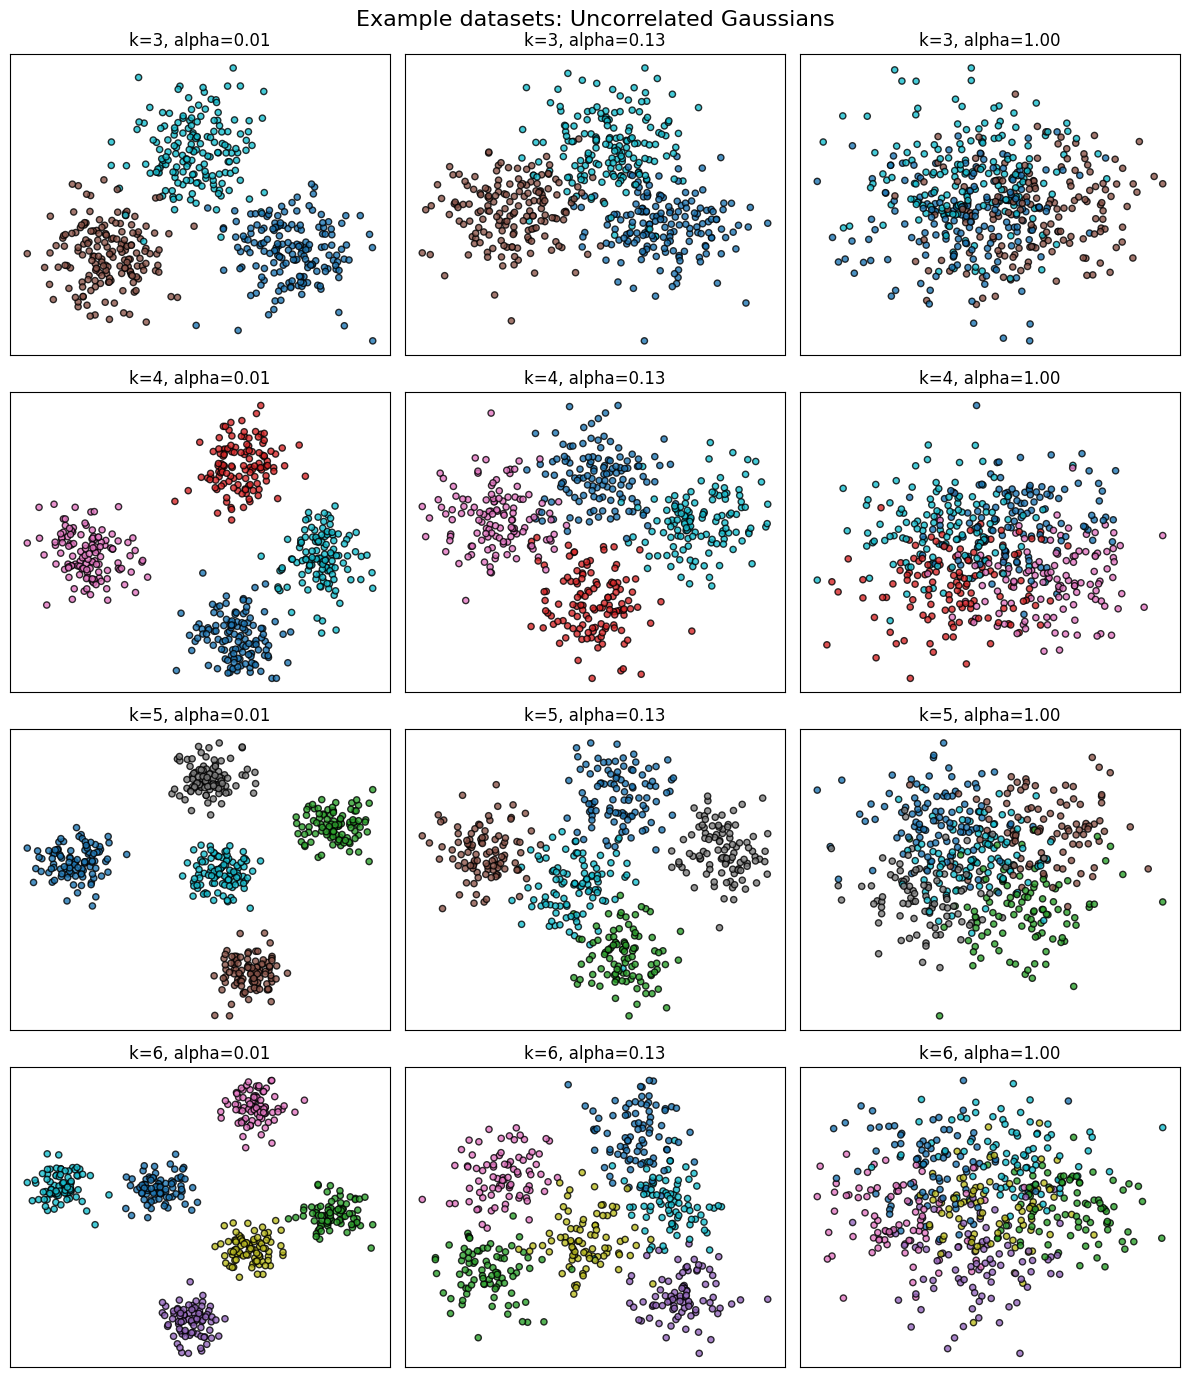

In [ ]:
ks = [3, 4, 5, 6]
alphas = np.logspace(np.log10(0.01), np.log10(1.0), 10)
anchors = [alphas[0], alphas[len(alphas)//2], alphas[-1]]

fig, axes = plt.subplots(len(ks), len(anchors), figsize=(12, 14))
for i, k in enumerate(ks):
    for j, a in enumerate(anchors):
        X, y = sim_alpha(
            alpha=a, k=k, seed=10*(i*len(anchors)+j),
            n_total=500, p=2,
            settings_by_k=settings_by_k_1,
            mult_range=(0.2, 4.0), mult_mode="linear",
            plotting=False
        )
        
        X_pca = PCA(n_components=2).fit_transform(X)
        ax = axes[i, j]
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab10", s=20, alpha=0.8, edgecolors="k")
        ax.set_title(f"k={k}, alpha={a:.2f}")
        ax.set_xticks([]); ax.set_yticks([])
        
plt.suptitle("Example datasets: Uncorrelated Gaussians", fontsize=16)
plt.tight_layout(); plt.show()

In [18]:
results_1 = benchmark_cluster_metrics(
    settings_by_k_1, 
    B=5, 
    external_metrics=["silhouette"],
    random_state=42
)

Benchmarking:   0%|          | 0/200 [00:00<?, ?it/s]

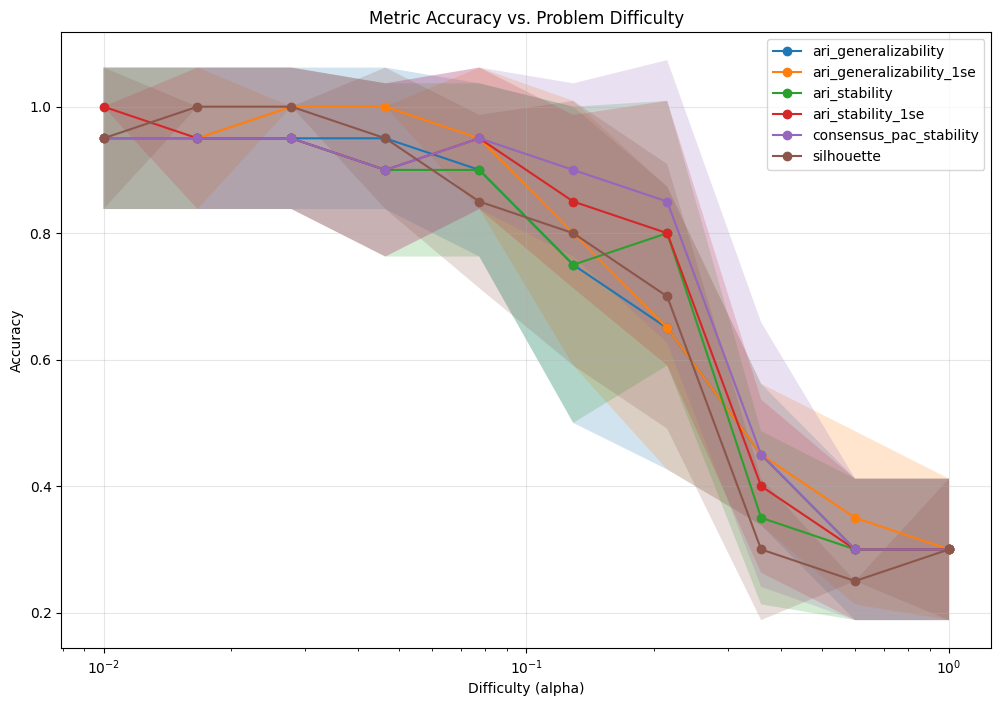

In [45]:
plot_accuracy_vs_alpha(results_1)

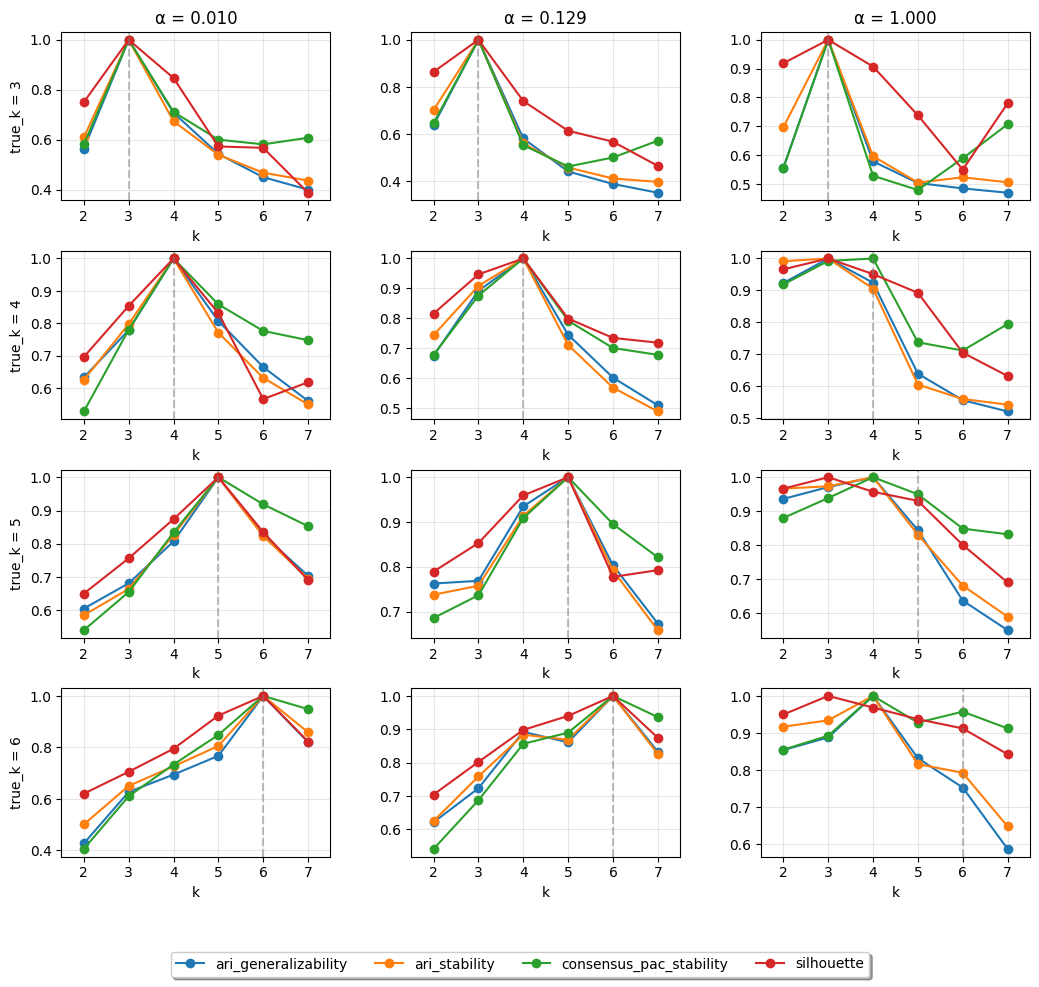

In [67]:
plot_metric_lineplots_grid(results_1, alphas)

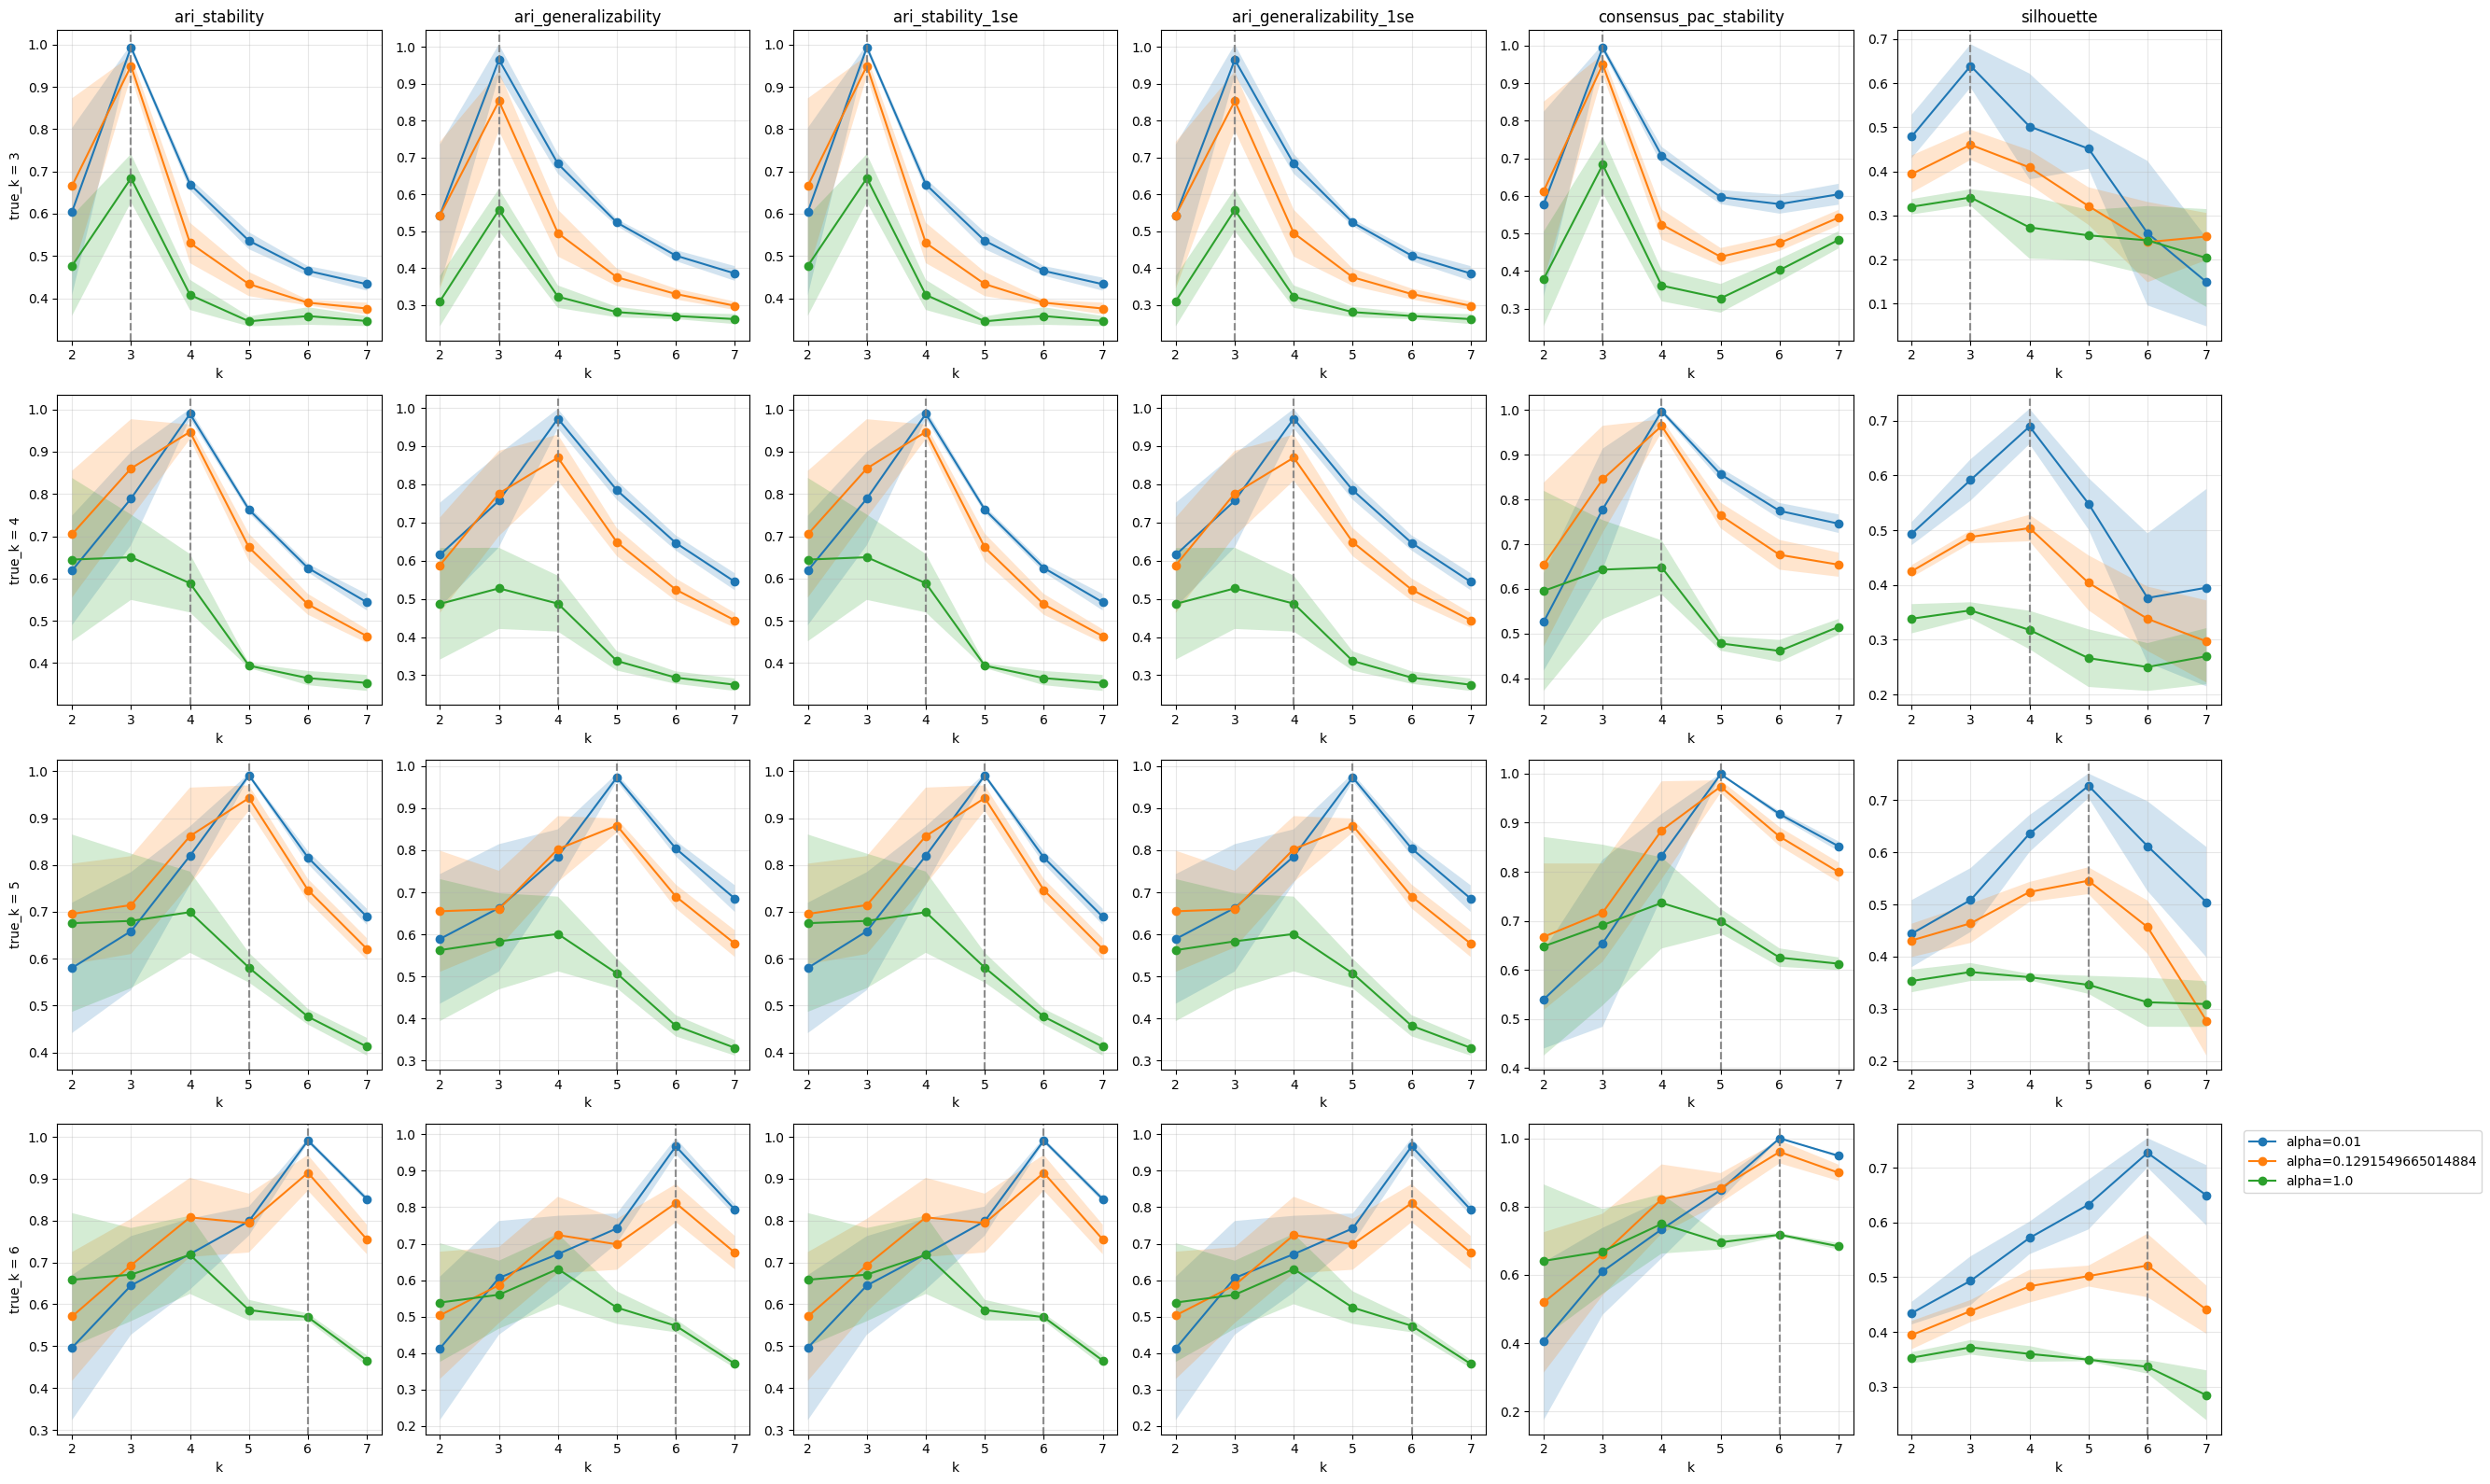

In [ ]:
plot_metric_lineplots_grid_alt(results_1, alphas)

In [ ]:
print_summary_stats(results_1)


--- Alpha = 0.01 ---
    ari_generalizability
Name: 0, dtype: object: Accuracy = 0.950 ± 0.224
    ari_generalizability_1se
Name: 1, dtype: object: Accuracy = 0.950 ± 0.224
    ari_stability
Name: 2, dtype: object: Accuracy = 0.950 ± 0.224
    ari_stability_1se
Name: 3, dtype: object: Accuracy = 1.000 ± 0.000
    consensus_pac_stability
Name: 4, dtype: object: Accuracy = 0.950 ± 0.224
    silhouette
Name: 5, dtype: object: Accuracy = 0.950 ± 0.224

--- Alpha = 0.016681005372000592 ---
    ari_generalizability
Name: 6, dtype: object: Accuracy = 0.950 ± 0.224
    ari_generalizability_1se
Name: 7, dtype: object: Accuracy = 0.950 ± 0.224
    ari_stability
Name: 8, dtype: object: Accuracy = 0.950 ± 0.224
    ari_stability_1se
Name: 9, dtype: object: Accuracy = 0.950 ± 0.224
    consensus_pac_stability
Name: 10, dtype: object: Accuracy = 0.950 ± 0.224
    silhouette
Name: 11, dtype: object: Accuracy = 1.000 ± 0.000

--- Alpha = 0.027825594022071243 ---
    ari_generalizability
Name: 12, dty